# Practical–03: Multi-Layer Perceptron for Complex Classification

## Experimenting with Activation Functions and Layer Configurations

**Prepared by:** Dr. Rajesh Kumar Maurya  
**Website:** https://www.rajeshmaurya.in

---

# Aim

To construct a Multi-Layer Perceptron for a complex multiclass classification problem and experimentally study the effect of:

- different activation functions;
- different hidden-layer configurations;
- model depth and width;
- number of trainable parameters;
- convergence behaviour;
- classification performance.

---

# Learning Outcomes

After completing this practical, the learner should be able to:

1. Build an MLP for multiclass classification.
2. Explain the effect of hidden-layer width and depth.
3. Compare ReLU, tanh, and logistic Sigmoid activations.
4. Compute the number of trainable parameters.
5. Interpret loss curves and convergence behaviour.
6. Compare models using validation accuracy, macro F1-score, and log loss.
7. Select a model using validation performance.
8. Evaluate the selected model using an unseen test set.
9. Analyse a confusion matrix and misclassified samples.

#### Image of Hand Written Dataset

1. Classification Problem 

This practical uses the **handwritten digits dataset**.

Each sample is an **8 × 8 grayscale image** representing one digit from **0 to 9**.

## Input

- 64 numerical pixel-intensity features.

## Output

- 10 mutually exclusive classes.

## Why is this a complex classification problem?

- There are ten classes rather than two.
- Different people write the same digit differently.
- Some digits have similar shapes, such as **3 and 8** or **1 and 7**.
- The relationship between pixel values and class labels is nonlinear.
- A linear classifier may not capture all shape variations.

In [7]:
import time 
import warnings
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import IPython
print(IPython.__version__)
from sklearn.datasets import load_digits
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)

np.random.seed(42)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("Libraries imported successfully.")

9.4.0
Libraries imported successfully.


In [5]:
#pip install ipython

# 2. Load the handwritten digits dataset

In [ ]:
digits = load_digits()

X = digits.data
y = digits.target
images = digits.images

print("Input matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Image dimensions:", images.shape[1:])
print("Number of classes:", len(np.unique(y)))
print("Class labels:", np.unique(y))
print("Pixel-value range:", (X.min(), X.max()))

Input matrix shape: (1797, 64)
Target vector shape: (1797,)
Image dimensions: (8, 8)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]
Pixel-value range: (np.float64(0.0), np.float64(16.0))


Visualize Sample Images 

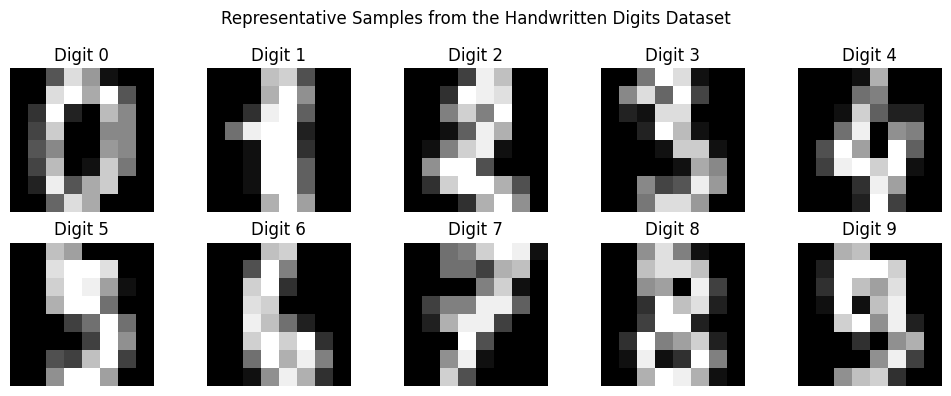

In [9]:
plt.figure(figsize=(10, 4))

for digit in range(10):
    sample_index = np.where(y == digit)[0][0]
    plt.subplot(2, 5, digit + 1)
    plt.imshow(images[sample_index], cmap="gray")
    plt.title(f"Digit {digit}")
    plt.axis("off")

plt.suptitle("Representative Samples from the Handwritten Digits Dataset")
plt.tight_layout()
plt.show()

# 3. Train-Validation-Test Split

The data is divided into three separate parts:

- **Training set:** used to learn weights and biases.
- **Validation set:** used to compare activation functions and layer configurations.
- **Test set:** used only for the final evaluation of the selected model.

This separation reduces the risk of choosing a model that performs well only on the test set.

In [10]:
X_train_validation, X_test, y_train_validation, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# From the remaining 80%, reserve 25% for validation.
# This gives approximately 60% train, 20% validation, and 20% test.
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_validation,
    y_train_validation,
    test_size=0.25,
    random_state=42,
    stratify=y_train_validation
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_validation.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1077
Validation samples: 360
Testing samples: 360


# 4. Feature Standardization

Neural networks train more reliably when input features have comparable scales.

Standardization transforms each feature using:

**standardized value = (original value − training mean) / training standard deviation**

The scaler is fitted only on the training data.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Mean of standardized training features:", np.mean(X_train_scaled))
print("Standard deviation of standardized training features:", np.std(X_train_scaled))

Mean of standardized training features: -2.6802041448703873e-18
Standard deviation of standardized training features: 0.9682458365518524


# 5. Multi-Layer Perceptron Architecture

For a layer containing:

- n_in input units;
- n_out output units;

the trainable parameters are:

Weights = n_in × n_out

Biases = n_out

Layer parameters = (n_in × n_out) + n_out

For an MLP, the total trainable parameters are the sum across all trainable layers.

In [12]:
def theoretical_parameter_count(input_units, hidden_layers, output_units):
    layer_sizes = [input_units] + list(hidden_layers) + [output_units]

    rows = []
    total_parameters = 0

    for layer_number in range(len(layer_sizes) - 1):
        n_in = layer_sizes[layer_number]
        n_out = layer_sizes[layer_number + 1]

        weight_count = n_in * n_out
        bias_count = n_out
        layer_parameters = weight_count + bias_count
        total_parameters += layer_parameters

        rows.append({
            "Connection": f"Layer {layer_number} → Layer {layer_number + 1}",
            "Input units": n_in,
            "Output units": n_out,
            "Weights": weight_count,
            "Biases": bias_count,
            "Layer parameters": layer_parameters
        })

    return pd.DataFrame(rows), total_parameters

# 6. Experimental Design

Three activation functions are compared:

### 1. ReLU

- output = max(0, z)
- computationally efficient;
- helps gradient flow for positive inputs.

### 2. tanh

- output range: −1 to 1;
- zero-centred;
- may saturate for large input magnitudes.

### 3. Logistic Sigmoid

- output range: 0 to 1;
- smooth;
- can suffer from vanishing gradients.

---

Three hidden-layer configurations are compared:

- **Small–Shallow:** (32)
- **Medium–Two-Layer:** (64, 32)
- **Deep–Three-Layer:** (128, 64, 32)

All experiments use the same data split, optimizer, learning rate, random seed, and stopping conditions.

In [14]:
activation_functions = ["relu", "tanh", "logistic"]

layer_configurations = {
    "Small-Shallow": (32,),
    "Medium-Two-Layer": (64, 32),
    "Deep-Three-Layer": (128, 64, 32)
}
experiment_plan = []

for activation in activation_functions:
    for configuration_name, hidden_layers in layer_configurations.items():
        _, parameter_count = theoretical_parameter_count(
            input_units=X_train_scaled.shape[1],
            hidden_layers=hidden_layers,
            output_units=10
        )

        experiment_plan.append({
            "Activation": activation,
            "Configuration": configuration_name,
            "Hidden layers": hidden_layers,
            "Trainable parameters": parameter_count
        })

experiment_plan = pd.DataFrame(experiment_plan)
display(experiment_plan)

,Activation,Configuration,Hidden layers,Trainable parameters
0,relu,Small-Shallow,"(32,)",2410
1,relu,Medium-Two-Layer,"(64, 32)",6570
2,relu,Deep-Three-Layer,"(128, 64, 32)",18986
3,tanh,Small-Shallow,"(32,)",2410
4,tanh,Medium-Two-Layer,"(64, 32)",6570
5,tanh,Deep-Three-Layer,"(128, 64, 32)",18986
6,logistic,Small-Shallow,"(32,)",2410
7,logistic,Medium-Two-Layer,"(64, 32)",6570
8,logistic,Deep-Three-Layer,"(128, 64, 32)",18986


# 7. Training Function

The following evaluation metrics are recorded for each experiment:

- training time;
- number of completed iterations;
- final training loss;
- training accuracy;
- validation accuracy;
- validation macro F1-score;
- validation log loss;
- trainable parameter count.

In [15]:
def actual_parameter_count(model):
    weight_parameters = sum(matrix.size for matrix in model.coefs_)
    bias_parameters = sum(vector.size for vector in model.intercepts_)
    return weight_parameters + bias_parameters


def train_and_evaluate_mlp(
    activation,
    hidden_layers,
    configuration_name,
    X_train_data,
    y_train_data,
    X_validation_data,
    y_validation_data
):

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="adam",
        learning_rate_init=0.001,
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    )

    start_time = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    elapsed_time = time.perf_counter() - start_time

    train_prediction = model.predict(X_train_data)
    validation_prediction = model.predict(X_validation_data)
    validation_probability = model.predict_proba(X_validation_data)

    result = {
        "Activation": activation,
        "Configuration": configuration_name,
        "Hidden layers": hidden_layers,
        "Parameters": actual_parameter_count(model),
        "Iterations": model.n_iter_,
        "Training time (s)": elapsed_time,
        "Final training loss": model.loss_,
        "Training accuracy": accuracy_score(
            y_train_data,
            train_prediction
        ),
        "Validation accuracy": accuracy_score(
            y_validation_data,
            validation_prediction
        ),
        "Validation macro F1": f1_score(
            y_validation_data,
            validation_prediction,
            average="macro"
        ),
        "Validation log loss": log_loss(
            y_validation_data,
            validation_probability
        )
    }

    return model, result

# 8. Run All Experiments

Nine models are trained:

3 activation dunctions x 3 layer configerations = 9 experiments

In [16]:
trained_models = {}
experiment_results = []

for activation in activation_functions:
    for configuration_name, hidden_layers in layer_configurations.items():

        model, result = train_and_evaluate_mlp(
            activation=activation,
            hidden_layers=hidden_layers,
            configuration_name=configuration_name,
            X_train_data=X_train_scaled,
            y_train_data=y_train,
            X_validation_data=X_validation_scaled,
            y_validation_data=y_validation
        )

        model_key = f"{activation} | {configuration_name}"
        trained_models[model_key] = model
        experiment_results.append(result)

        print(
            f"Completed: {model_key} | "
            f"Validation accuracy = {result['Validation accuracy']:.4f}"
        )

results_df = pd.DataFrame(experiment_results)
print("\nAll experiments completed.")

Completed: relu | Small-Shallow | Validation accuracy = 0.9500
Completed: relu | Medium-Two-Layer | Validation accuracy = 0.9361
Completed: relu | Deep-Three-Layer | Validation accuracy = 0.9722
Completed: tanh | Small-Shallow | Validation accuracy = 0.9444
Completed: tanh | Medium-Two-Layer | Validation accuracy = 0.9472
Completed: tanh | Deep-Three-Layer | Validation accuracy = 0.9639
Completed: logistic | Small-Shallow | Validation accuracy = 0.9556
Completed: logistic | Medium-Two-Layer | Validation accuracy = 0.9500
Completed: logistic | Deep-Three-Layer | Validation accuracy = 0.9417

All experiments completed.


# 9. Experimental Results

Models are ranked using validation accuracy.

When validation accuracies are close, validation log loss and model complexity should also be considered.

In [17]:
ranked_results = results_df.sort_values(
    by=["Validation accuracy", "Validation macro F1"],
    ascending=[False, False]
).reset_index(drop=True)

ranked_results.index = ranked_results.index + 1
ranked_results.index.name = "Rank"

display(ranked_results)

,Activation,Configuration,Hidden layers,Parameters,Iterations,Training time (s),Final training loss,Training accuracy,Validation accuracy,Validation macro F1,Validation log loss
Rank,,,,,,,,,,,
1,relu,Deep-Three-Layer,"(128, 64, 32)",18986,36,0.5870,0.0026,0.9954,0.9722,0.9721,0.1073
2,tanh,Deep-Three-Layer,"(128, 64, 32)",18986,30,0.5392,0.0224,0.9851,0.9639,0.9635,0.2254
3,logistic,Small-Shallow,"(32,)",2410,86,0.4972,0.1094,0.9805,0.9556,0.9556,0.2374
4,relu,Small-Shallow,"(32,)",2410,62,0.2711,0.0305,0.9935,0.9500,0.9497,0.1538
5,logistic,Medium-Two-Layer,"(64, 32)",6570,83,0.8739,0.0854,0.9796,0.9500,0.9495,0.2308
6,tanh,Medium-Two-Layer,"(64, 32)",6570,40,0.2728,0.0339,0.9870,0.9472,0.9470,0.2268
7,tanh,Small-Shallow,"(32,)",2410,53,0.2039,0.0622,0.9805,0.9444,0.9446,0.2286
8,logistic,Deep-Three-Layer,"(128, 64, 32)",18986,93,2.3310,0.0499,0.9889,0.9417,0.9416,0.2279
9,relu,Medium-Two-Layer,"(64, 32)",6570,38,0.2415,0.0118,0.9898,0.9361,0.9363,0.2172


Validation Accuracy Comparison

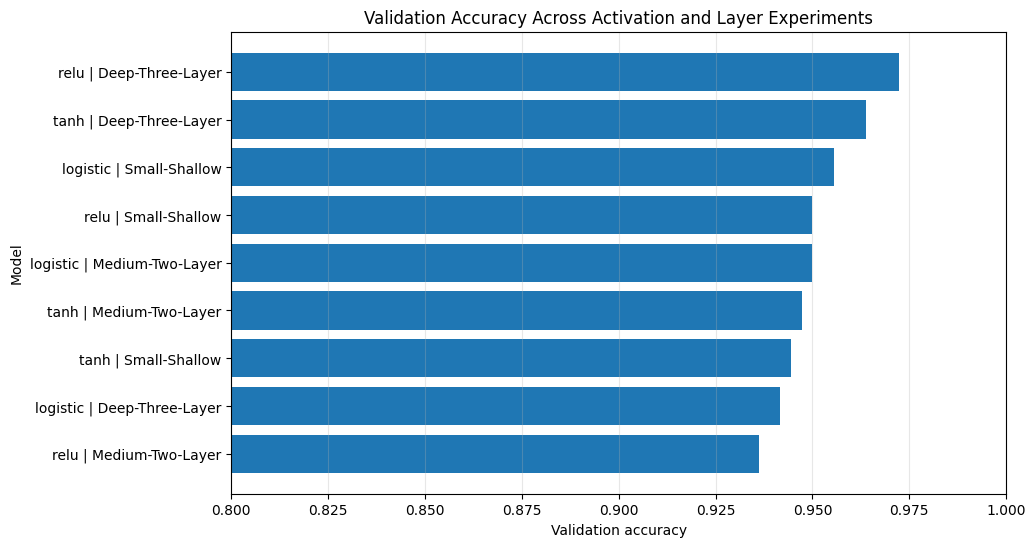

In [18]:
# Create a label combining activation function and configuration
plot_df = ranked_results.copy()
plot_df["Model"] = (
    plot_df["Activation"] + " | " + plot_df["Configuration"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["Validation accuracy"]
)

plt.gca().invert_yaxis()

plt.title("Validation Accuracy Across Activation and Layer Experiments")
plt.xlabel("Validation accuracy")
plt.ylabel("Model")

plt.xlim(0.80, 1.00)
plt.grid(axis="x", alpha=0.3)

plt.show()

# Effect of Activation Function

The average validation performance across all layer configurations is calculated for each activations.

In [19]:
activation_summary = (
    results_df
    .groupby("Activation", as_index=False)
    .agg({
        "Validation accuracy": "mean",
        "Validation macro F1": "mean",
        "Validation log loss": "mean",
        "Training time (s)": "mean",
        "Iterations": "mean"
    })
    .sort_values("Validation accuracy", ascending=False)
)

display(activation_summary)

,Activation,Validation accuracy,Validation macro F1,Validation log loss,Training time (s),Iterations
1,relu,0.9528,0.9527,0.1594,0.3665,45.3333
2,tanh,0.9519,0.9517,0.2269,0.3387,41.0000
0,logistic,0.9491,0.9489,0.2320,1.2340,87.3333


### Sir instructed us to complete the notebook up to this point.

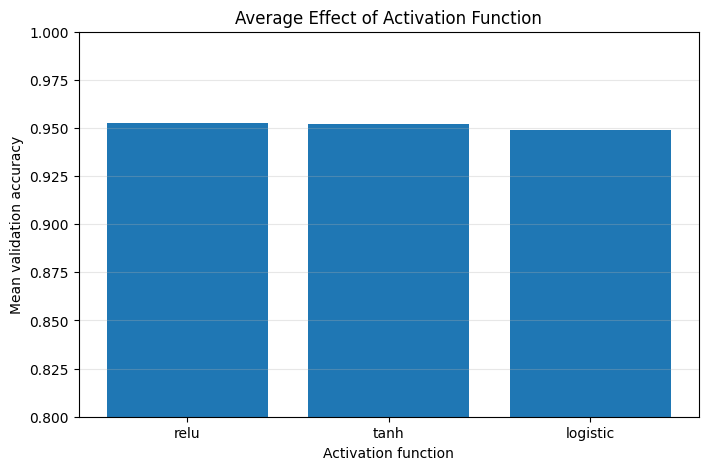

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    activation_summary["Activation"],
    activation_summary["Validation accuracy"]
)

plt.xlabel("Activation function")
plt.ylabel("Mean validation accuracy")
plt.title("Average Effect of Activation Function")

plt.ylim(0.80, 1.00)
plt.grid(axis="y", alpha=0.3)

plt.show()

# Effect of Layer Configuration

In [21]:
configuration_summary = (
    results_df
    .groupby("Configuration", as_index=False)
    .agg({
        "Parameters": "mean",
        "Validation accuracy": "mean",
        "Validation macro F1": "mean",
        "Validation log loss": "mean",
        "Training time (s)": "mean"
    })
    .sort_values("Validation accuracy", ascending=False)
)

display(configuration_summary)

,Configuration,Parameters,Validation accuracy,Validation macro F1,Validation log loss,Training time (s)
0,Deep-Three-Layer,18986.0000,0.9593,0.9591,0.1869,1.1524
2,Small-Shallow,2410.0000,0.9500,0.9500,0.2066,0.3240
1,Medium-Two-Layer,6570.0000,0.9444,0.9443,0.2249,0.4628


Plot the average validation accuracy by layer configuration

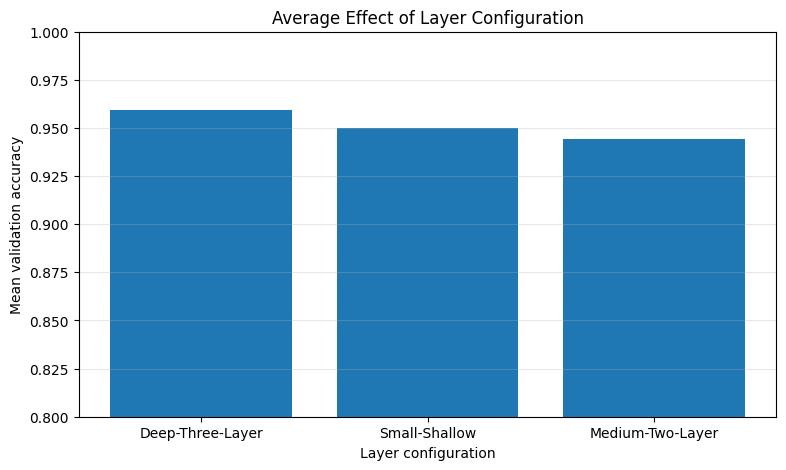

In [22]:
plt.figure(figsize=(9, 5))

plt.bar(
    configuration_summary["Configuration"],
    configuration_summary["Validation accuracy"]
)

plt.xlabel("Layer configuration")
plt.ylabel("Mean validation accuracy")
plt.title("Average Effect of Layer Configuration")

plt.ylim(0.80, 1.00)
plt.grid(axis="y", alpha=0.3)

plt.show()

# Select the best model for each activation function

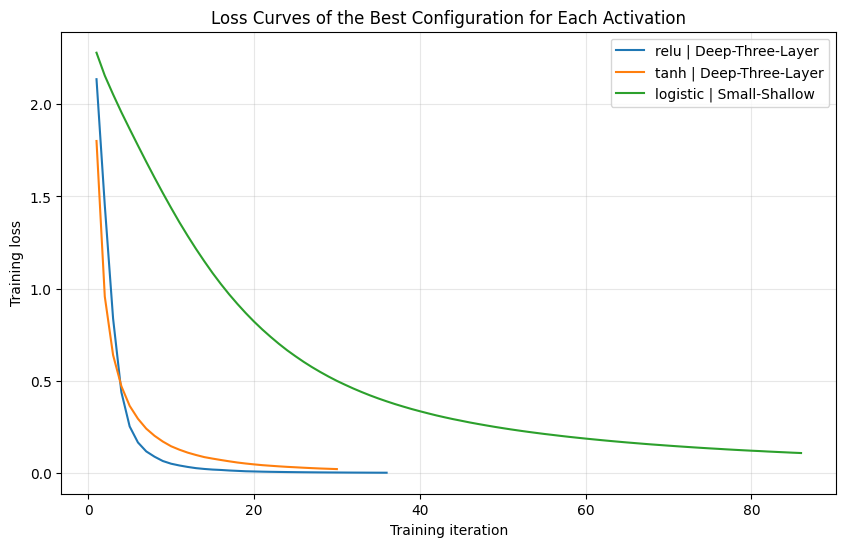

In [23]:
best_models = {}

for activation in activation_functions:
    activation_models = ranked_results[
        ranked_results["Activation"] == activation
    ]

    best_row = activation_models.iloc[0]
    model_key = f"{best_row['Activation']} | {best_row['Configuration']}"
    best_models[model_key] = trained_models[model_key]

# Plot loss curves
plt.figure(figsize=(10, 6))

for model_name, model in best_models.items():
    plt.plot(
        range(1, len(model.loss_curve_) + 1),
        model.loss_curve_,
        label=model_name
    )

plt.title("Loss Curves of the Best Configuration for Each Activation")
plt.xlabel("Training iteration")
plt.ylabel("Training loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 11. Select the Best Model

In [24]:
X_development = np.vstack([X_train, X_validation])
y_development = np.concatenate([y_train, y_validation])

final_scaler = StandardScaler()

X_development_scaled = final_scaler.fit_transform(X_development)
X_test_final_scaled = final_scaler.transform(X_test)

final_model = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    activation=best_activation,
    solver="adam",
    learning_rate_init=0.001,
    batch_size=64,
    max_iter=350,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=25,
    random_state=42
)

final_model.fit(X_development_scaled, y_development)

print("Final training completed.")
print("Iterations:", final_model.n_iter_)
print("Trainable parameters:", actual_parameter_count(final_model))

NameError: name 'best_hidden_layers' is not defined